# Potencial de Oleaje

**Materia:** Energía del agua

**Alumnxs:** 

- Montserrat González  
- Rosario Navarro
- Leonel Navarro
- Ernesto Maldonado

**Fecha:** 24 de marzo 2026  

---

## 1. Introducción

La energía undimotriz — aquella contenida en el oleaje oceánico — representa una de las fuentes renovables con mayor densidad energética por unidad de frente de ola. Su aprovechamiento requiere, como primer paso, la **caracterización del recurso** en un sitio de interés.

En este trabajo se analiza un año completo (2025) de registros espectrales de oleaje obtenidos de una boya oceánica del sistema NDBC (National Data Buoy Center, NOAA). A partir de la densidad espectral de energía $S(f)$ se calculan los parámetros de oleaje y la potencia disponible siguiendo la metodología de **Silva Casarín R. (2005, pp. 61-65)**.

### Objetivos

1. Calcular los parámetros espectrales del oleaje ($H_s$, $T_e$, $F_p$, $P_w$) a partir de los momentos del espectro.
2. Graficar la serie temporal de potencia del oleaje.
3. Determinar la potencia media anual y los promedios mensuales.
4. Construir diagramas de dispersión $H_s$–$T_e$ y $H_s$–$F_p$.
5. Estimar el recurso energético anual (GWh/m/año) mediante dos métodos:
   - **Método 1:** Sumatoria directa de potencia.
   - **Método 2:** Matriz de dispersión $H_s$–$T_e$.

## 2. Marco teórico

### Espectro de oleaje

El estado del mar en un punto se describe mediante la **densidad espectral de energía** $S(f)$, que representa la distribución de la energía del oleaje en función de la frecuencia $f$ (Hz). En la práctica, los espectrómetros de las boyas proporcionan $S(f)$ discretizado en $N$ bandas de frecuencia, cada una con un ancho $\Delta f_i$.

### Momentos espectrales

A partir del espectro discreto se calculan los **momentos espectrales** de orden $n$:

$$m_n = \sum_{i=1}^{N} f_i^n \cdot S(f_i) \cdot \Delta f_i$$

Los momentos de interés son:

| Momento | Expresión | Significado físico |
|---------|-----------|-------------------|
| $m_0$ | $\sum S(f_i) \cdot \Delta f_i$ | Varianza total de la superficie = energía total del espectro |
| $m_{-1}$ | $\sum \frac{S(f_i)}{f_i} \cdot \Delta f_i$ | Ponderación hacia bajas frecuencias (relacionado con transporte de energía) |
| $m_1$ | $\sum f_i \cdot S(f_i) \cdot \Delta f_i$ | Frecuencia media del espectro |

### Parámetros derivados

| Parámetro | Fórmula | Descripción |
|-----------|---------|-------------|
| **Altura significante** | $H_s = 4\sqrt{m_0}$ | Medida estadística de la altura de ola (promedio del tercio superior) |
| **Período de energía** | $T_e = m_{-1} / m_0$ | Período asociado al transporte de energía del oleaje |
| **Frecuencia pico** | $F_p = f$ en $\max[S(f)]$ | Frecuencia donde el espectro alcanza su máximo |

### Potencia del oleaje

La **densidad de flujo de energía** (potencia por metro de frente de ola) se obtiene de la teoría lineal de oleaje en aguas profundas:

$$P_w = \frac{\rho g^2}{64\pi} H_s^2 T_e$$

donde $\rho = 1025$ kg/m³ (densidad del agua de mar) y $g = 9.81$ m/s². El coeficiente resultante es:

$$\frac{\rho g^2}{64\pi} = \frac{1025 \times 9.81^2}{64\pi} \approx 490.6 \text{ W/m}$$

Por lo tanto: $P_w \approx 0.4906 \cdot H_s^2 \cdot T_e$ (en kW/m).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 3. Carga y preparación de datos

Los datos provienen de una boya oceánica del NDBC y fueron descargados como archivo Excel. El archivo contiene **~15,538 observaciones cada 30 minutos** correspondientes al año 2025, con la siguiente estructura:

- **Columnas temporales:** `#YY` (año), `MM` (mes), `DD` (día), `hh` (hora), `mm` (minuto).
- **47 columnas de frecuencia** (de 0.02 a 0.485 Hz): cada una contiene la densidad espectral $S(f_i)$ en m²/Hz.
- **Columnas pre-calculadas:** $m_0$, $m_1$, $m_{-1}$, $H_{m0}$, $T_e$, $P_w$ (se usarán para validación).
- **$\Delta f$ promedio:** El archivo utiliza un ancho de banda promedio $\Delta f = 0.006556$ Hz para los cálculos de momentos espectrales.

**Nota:** El mes de abril no tiene registros en los datos disponibles.

In [2]:
# Cargar archivo Excel
datos_raw = pd.read_excel("data/datos_oleaje_2025.xlsx", sheet_name="Datos")
datos_raw.columns = datos_raw.columns.astype(str).str.strip()

# Identificar columnas de frecuencia (nombres parseables como float entre 0 y 1)
freq_cols = []
for col in datos_raw.columns:
    try:
        val = float(col)
        if 0 < val < 1:
            freq_cols.append(col)
    except ValueError:
        pass

# Frecuencias centrales
frecuencias = np.array([float(c) for c in freq_cols])

# Δf promedio (usado en las fórmulas del archivo Excel)
delta_f = 0.006556

print(f"Bandas de frecuencia: {len(frecuencias)} bins ({frecuencias[0]} - {frecuencias[-1]} Hz)")
print(f"Δf promedio: {delta_f} Hz")

# Trabajar con copia limpia
df = datos_raw.copy()

# Columnas numéricas de frecuencia
for col in freq_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar columnas auxiliares del Excel
cols_aux = ["FRECUENCIAS", "Δ FRECUENCIA", "PROM Δ FRECUENCIA",
            "Pw (simplificada)"]
df = df.drop(columns=[c for c in cols_aux if c in df.columns], errors="ignore")

print(f"\nObservaciones cargadas: {len(df)}")
print(f"Columnas: {list(df.columns[:7])} ... {list(df.columns[-5:])}")


Bandas de frecuencia: 47 bins (0.02 - 0.485 Hz)
Δf promedio: 0.006556 Hz

Observaciones cargadas: 15538
Columnas: ['#YY', 'MM', 'DD', 'hh', 'mm', '0.02', '0.0325'] ... ['m1', 'm-1', 'Hm0', 'Te', 'Pw']


### Construcción de la serie temporal

Se construyen las columnas temporales a partir de las columnas de año, mes, día y hora para generar un índice `datetime` que permita el análisis temporal y las agrupaciones por mes.

In [3]:
# Columnas de tiempo
cols_time = ["#YY", "MM", "DD", "hh", "mm"]

# Convertir a numérico (manejo de errores)
for col in cols_time:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar filas inválidas
df = df.dropna(subset=cols_time)

# Convertir a enteros
for col in cols_time:
    df[col] = df[col].astype(int)


In [4]:
df["datetime"] = pd.to_datetime(
    df["#YY"].astype(str)
    + "-"
    + df["MM"].astype(str).str.zfill(2)
    + "-"
    + df["DD"].astype(str).str.zfill(2)
    + " "
    + df["hh"].astype(str).str.zfill(2)
    + ":"
    + df["mm"].astype(str).str.zfill(2)
)

# Ordenar
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Período: {df['datetime'].iloc[0]} a {df['datetime'].iloc[-1]}")
print(f"Observaciones: {len(df)}")
df.head()


Período: 2025-01-01 00:10:00 a 2025-12-31 23:40:00
Observaciones: 15538


,#YY,MM,DD,hh,mm,0.02,0.0325,0.0375,0.0425,0.0475,0.0525,0.0575,0.0625,0.0675,0.0725,0.0775,0.0825,0.0875,0.0925,0.1,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.3,0.31,0.32,0.33,0.34,0.35,0.365,0.385,0.405,0.425,0.445,0.465,0.485,m0,m1,m-1,Hm0,Te,Pw,datetime
0,2025,1,1,0,10,0,0.0,0.0,0.0,0.00,0.01,0.12,0.59,1.90,4.33,6.84,6.61,3.83,2.90,4.19,4.53,2.80,2.78,1.79,2.25,0.88,0.77,0.83,0.54,0.40,0.31,0.37,0.26,0.19,0.24,0.16,0.11,0.10,0.10,0.06,0.09,0.10,0.07,0.06,0.05,0.05,0.04,0.02,0.01,0.01,0.00,0.0,0.336234,0.036720,3.458680,2.319429,10.286514,27.149537,2025-01-01 00:10:00
1,2025,1,1,0,40,0,0.0,0.0,0.0,0.00,0.00,0.10,0.59,2.75,4.43,4.31,3.89,3.40,2.77,3.00,6.65,3.93,2.13,1.75,1.28,0.94,0.41,0.68,0.87,0.44,0.20,0.39,0.18,0.27,0.24,0.18,0.19,0.13,0.16,0.08,0.09,0.04,0.08,0.07,0.02,0.05,0.04,0.01,0.01,0.01,0.01,0.0,0.306603,0.034212,3.104594,2.214871,10.125766,24.370070,2025-01-01 00:40:00
2,2025,1,1,1,10,0,0.0,0.0,0.0,0.00,0.01,0.10,0.46,2.02,4.76,6.68,6.03,3.99,2.79,2.70,3.82,6.50,2.21,3.01,1.79,0.35,0.89,0.92,0.43,0.20,0.47,0.33,0.23,0.27,0.16,0.13,0.11,0.11,0.07,0.08,0.06,0.10,0.03,0.06,0.04,0.05,0.03,0.03,0.02,0.01,0.01,0.0,0.341282,0.037386,3.485070,2.336775,10.211694,27.356686,2025-01-01 01:10:00
3,2025,1,1,1,40,0,0.0,0.0,0.0,0.03,0.05,0.17,0.85,2.57,4.96,7.21,6.20,3.64,3.35,3.98,4.47,4.61,3.65,1.56,1.90,1.22,0.51,0.44,0.33,0.31,0.22,0.18,0.13,0.20,0.24,0.14,0.08,0.08,0.09,0.08,0.06,0.10,0.06,0.04,0.03,0.03,0.03,0.01,0.01,0.01,0.01,0.0,0.352951,0.037327,3.702509,2.376388,10.490146,29.063513,2025-01-01 01:40:00
4,2025,1,1,2,10,0,0.0,0.0,0.0,0.01,0.04,0.21,0.57,1.97,3.56,5.36,6.12,5.04,3.09,2.61,3.98,3.65,4.19,2.12,1.22,0.50,1.21,0.71,0.52,0.23,0.52,0.37,0.21,0.20,0.14,0.07,0.17,0.08,0.06,0.05,0.06,0.06,0.06,0.03,0.03,0.03,0.02,0.01,0.01,0.00,0.00,0.0,0.321812,0.035099,3.288285,2.269140,10.218025,25.811991,2025-01-01 02:10:00


## 4. Cálculo de parámetros espectrales (Punto 4)

A partir del espectro discreto $S(f_i)$ y los anchos de banda $\Delta f_i$ extraídos del archivo, se calculan los momentos espectrales para cada observación horaria. Con estos momentos se obtienen los parámetros de oleaje: $H_s$, $T_e$, $F_p$ y $P_w$.

Este cálculo se realiza de forma vectorizada sobre las 6,467 observaciones simultáneamente.

In [5]:
# Matriz de densidad espectral: (N_obs, 47)
S = df[freq_cols].values.astype(float)

# --- Momentos espectrales (usando Δf promedio) ---
m0_calc     = np.sum(S, axis=1) * delta_f                   # m₀ = Δf · Σ S(fᵢ)
m_neg1_calc = np.sum(S / frecuencias, axis=1) * delta_f     # m₋₁ = Δf · Σ S(fᵢ)/fᵢ
m1_calc     = np.sum(S * frecuencias, axis=1) * delta_f     # m₁ = Δf · Σ fᵢ·S(fᵢ)

# --- Parámetros derivados ---
Hs_calc = 4.0 * np.sqrt(m0_calc)                            # Altura significante
Te_calc = m_neg1_calc / m0_calc                              # Período de energía
Fp_calc = frecuencias[np.argmax(S, axis=1)]                  # Frecuencia pico

# --- Potencia del oleaje (kW/m) ---
rho = 1025       # kg/m³
g   = 9.81       # m/s²
coeff = rho * g**2 / (64 * np.pi)                            # ≈ 490.6 W/m
Pw_calc = coeff * Hs_calc**2 * Te_calc / 1000                # kW/m

# Almacenar en el DataFrame
df["m0_calc"]  = m0_calc
df["m1_calc"]  = m1_calc
df["m-1_calc"] = m_neg1_calc
df["Hs_calc"]  = Hs_calc
df["Te_calc"]  = Te_calc
df["Fp_calc"]  = Fp_calc
df["Pw_calc"]  = Pw_calc

print(f"Coeficiente ρg²/(64π) = {coeff:.4f} W/m")
print(f"Δf promedio utilizado = {delta_f} Hz")
print(f"Cálculos completados para {len(df)} observaciones.")


Coeficiente ρg²/(64π) = 490.6051 W/m
Δf promedio utilizado = 0.006556 Hz
Cálculos completados para 15538 observaciones.


### Tabla de resultados espectrales

Se muestran las primeras 20 observaciones con los parámetros calculados a partir de los momentos espectrales.

In [6]:
tabla = df[["datetime", "Hs_calc", "Te_calc", "Fp_calc", "Pw_calc"]].copy()
tabla.columns = ["Fecha/Hora", "Hs (m)", "Te (s)", "Fp (Hz)", "Pw (kW/m)"]
tabla.head(20)


,Fecha/Hora,Hs (m),Te (s),Fp (Hz),Pw (kW/m)
0,2025-01-01 00:10:00,2.319508,10.286514,0.0775,27.151378
1,2025-01-01 00:40:00,2.214946,10.125766,0.1100,24.371722
2,2025-01-01 01:10:00,2.336854,10.211694,0.0775,27.358540
3,2025-01-01 01:40:00,2.376468,10.490146,0.0775,29.065484
4,2025-01-01 02:10:00,2.269217,10.218025,0.0825,25.813740
5,2025-01-01 02:40:00,2.232400,10.230053,0.1100,25.012315
6,2025-01-01 03:10:00,2.292899,10.093605,0.0775,26.034444
7,2025-01-01 03:40:00,2.169489,10.167597,0.0775,23.478231
8,2025-01-01 04:10:00,1.994932,10.028877,0.1200,19.581258
9,2025-01-01 04:40:00,2.296556,10.401598,0.0875,26.914498


### Validación contra valores pre-calculados

El archivo CSV incluye valores de $H_s$, $T_e$, $F_p$ y $P_w$ pre-calculados. Se comparan con los valores obtenidos mediante momentos espectrales para verificar la correcta implementación del método.

In [7]:
# Convertir columnas pre-calculadas a numérico
for col in ["m0", "m1", "m-1", "Hm0", "Te", "Pw"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("=== Validación: valores calculados vs pre-calculados ===\n")

validaciones = [
    ("m0",       "m0_calc",  "m0"),
    ("m1",       "m1_calc",  "m1"),
    ("m-1",      "m-1_calc", "m-1"),
    ("Hm0 (m)",  "Hs_calc",  "Hm0"),
    ("Te (s)",   "Te_calc",  "Te"),
    ("Pw (kW/m)","Pw_calc",  "Pw"),
]

for label, calc_col, ref_col in validaciones:
    if ref_col not in df.columns:
        print(f"{label}: columna '{ref_col}' no encontrada, saltando.\n")
        continue
    diff = (df[calc_col] - df[ref_col]).abs()
    pct  = (diff / df[ref_col].abs().replace(0, np.nan) * 100)
    print(f"{label}:")
    print(f"  Error absoluto medio:   {diff.mean():.8f}")
    print(f"  Error porcentual medio: {pct.mean():.6f}%")
    print(f"  Error absoluto máximo:  {diff.max():.8f}")
    print()


=== Validación: valores calculados vs pre-calculados ===

m0:
  Error absoluto medio:   0.00001795
  Error porcentual medio: 0.006780%
  Error absoluto máximo:  0.00018556

m1:
  Error absoluto medio:   0.00000193
  Error porcentual medio: 0.006780%
  Error absoluto máximo:  0.00001405

m-1:
  Error absoluto medio:   0.00020075
  Error porcentual medio: 0.006780%
  Error absoluto máximo:  0.00261151

Hm0 (m):
  Error absoluto medio:   0.00006572
  Error porcentual medio: 0.003390%
  Error absoluto máximo:  0.00022432

Te (s):
  Error absoluto medio:   0.00000000
  Error porcentual medio: 0.000000%
  Error absoluto máximo:  0.00000000

Pw (kW/m):
  Error absoluto medio:   0.00157585
  Error porcentual medio: 0.006780%
  Error absoluto máximo:  0.02049955



### Selección de variables para el análisis

Una vez validados los cálculos espectrales, se utilizan los **valores calculados** ($H_s$, $T_e$, $F_p$, $P_w$) para el resto del análisis.

In [8]:
df = df[["datetime", "Hs_calc", "Te_calc", "Fp_calc", "Pw_calc"]].copy()
df.columns = ["datetime", "Hs (m)", "Te (s)", "Fp (Hz)", "Pw (kW/m)"]
print(f"Variables seleccionadas: {len(df)} registros")
df.head()


Variables seleccionadas: 15538 registros


,datetime,Hs (m),Te (s),Fp (Hz),Pw (kW/m)
0,2025-01-01 00:10:00,2.319508,10.286514,0.0775,27.151378
1,2025-01-01 00:40:00,2.214946,10.125766,0.1100,24.371722
2,2025-01-01 01:10:00,2.336854,10.211694,0.0775,27.358540
3,2025-01-01 01:40:00,2.376468,10.490146,0.0775,29.065484
4,2025-01-01 02:10:00,2.269217,10.218025,0.0825,25.813740


## 5. Serie temporal de potencia del oleaje (Punto 5)

La gráfica de $P_w$ a resolución horaria permite observar la **variabilidad del recurso energético** a lo largo del año. Se esperan fluctuaciones significativas asociadas a la estacionalidad (tormentas invernales vs. calma veraniega) y a eventos individuales de alta energía.

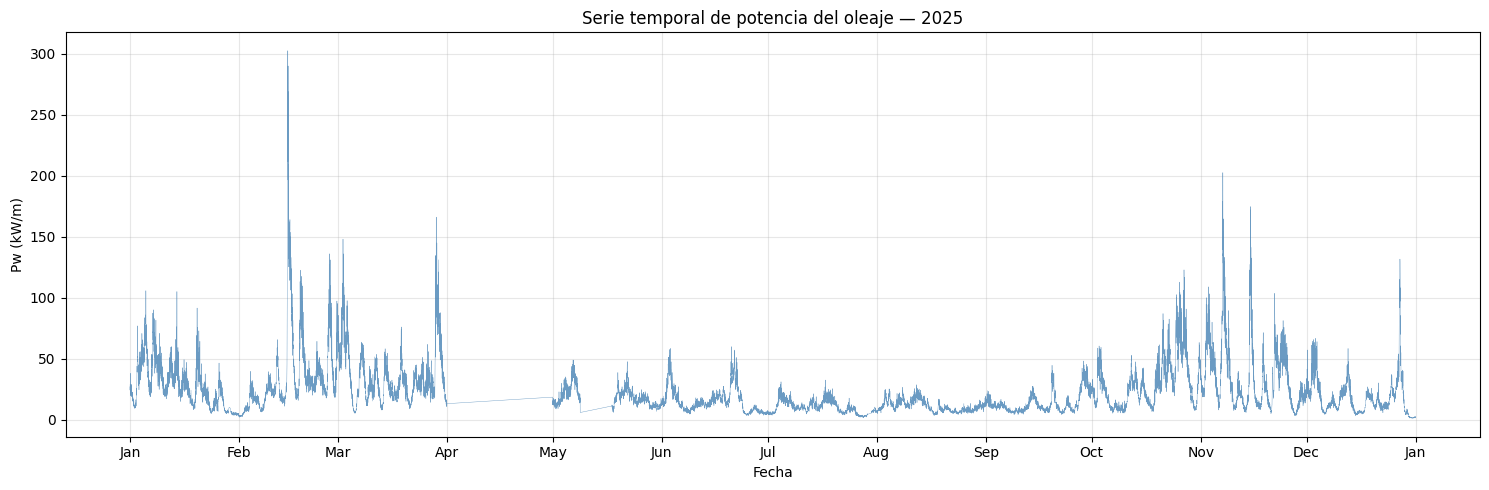

In [9]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df["datetime"], df["Pw (kW/m)"], linewidth=0.3, color="steelblue", alpha=0.8)
ax.set_xlabel("Fecha")
ax.set_ylabel("Pw (kW/m)")
ax.set_title("Serie temporal de potencia del oleaje — 2025")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Promedios mensuales de Pw (Punto 9)

La distribución mensual de la potencia permite identificar la **estacionalidad del recurso**. Esto es fundamental para la planificación energética: un recurso con alta variabilidad estacional requiere complementarse con otras fuentes o con sistemas de almacenamiento.

In [10]:
df["mes"] = df["datetime"].dt.month

promedio_mensual = df.groupby("mes")["Pw (kW/m)"].mean()

meses_dict = {1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
              7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"}
promedio_mensual.index = [meses_dict[m] for m in promedio_mensual.index]

promedio_anual = df["Pw (kW/m)"].mean()

print(f"Meses con datos: {len(promedio_mensual)}\n")
print("Promedios mensuales de Pw (kW/m):\n")
for mes, val in zip(promedio_mensual.index, promedio_mensual.values):
    print(f"  {mes}: {val:.2f} kW/m")
print(f"\n  Promedio anual: {promedio_anual:.2f} kW/m")


Meses con datos: 11

Promedios mensuales de Pw (kW/m):

  Ene: 28.40 kW/m
  Feb: 36.96 kW/m
  Mar: 35.46 kW/m
  May: 19.11 kW/m
  Jun: 15.60 kW/m
  Jul: 10.56 kW/m
  Ago: 11.30 kW/m
  Sep: 13.65 kW/m
  Oct: 30.34 kW/m
  Nov: 35.41 kW/m
  Dic: 18.33 kW/m

  Promedio anual: 23.25 kW/m


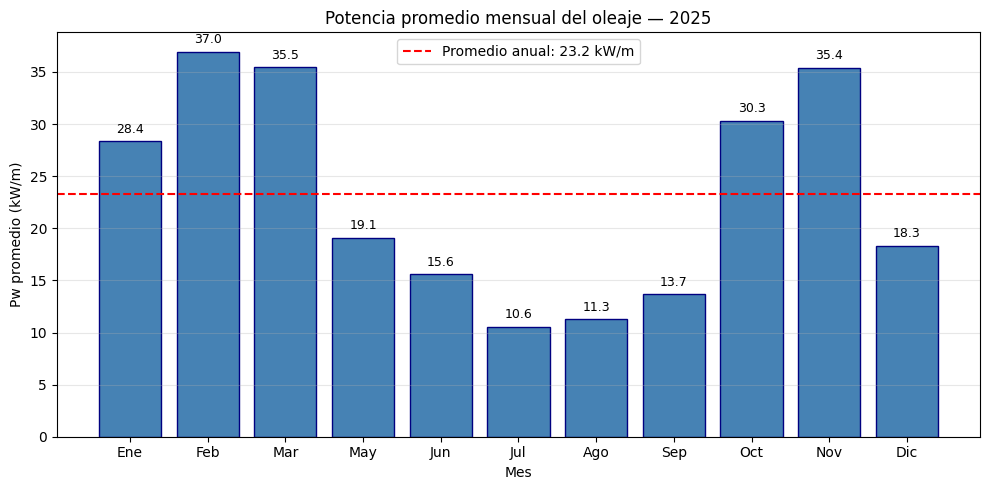

In [11]:
n_meses = len(promedio_mensual)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(n_meses), promedio_mensual.values, color="steelblue", edgecolor="navy")
ax.set_xticks(range(n_meses))
ax.set_xticklabels(promedio_mensual.index)
ax.set_xlabel("Mes")
ax.set_ylabel("Pw promedio (kW/m)")
ax.set_title("Potencia promedio mensual del oleaje — 2025")
ax.axhline(y=promedio_anual, color="red", linestyle="--", linewidth=1.5,
           label=f"Promedio anual: {promedio_anual:.1f} kW/m")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Etiquetas de valor sobre cada barra
for bar, val in zip(bars, promedio_mensual.values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 7. Potencia promedio anual (Punto 6)

La potencia media anual es el indicador principal para evaluar la **viabilidad energética** de un sitio. Como referencia, sitios con $P_w > 20$ kW/m se consideran de interés para el aprovechamiento de energía del oleaje.

In [12]:
print(f"Potencia promedio anual: {promedio_anual:.2f} kW/m")


Potencia promedio anual: 23.25 kW/m


## 8. Recurso energético anual — Método 1 (Punto 10)

La energía anual disponible por metro de frente de ola se obtiene integrando la potencia en el tiempo. Con datos cada 30 minutos, la integral se aproxima como:

$$E = \sum_{i=1}^{N} P_{w,i} \cdot \Delta t \quad \text{donde } \Delta t = 0.5 \text{ horas}$$

Se presentan dos cálculos:
- **Sumatoria directa:** suma de las $N$ observaciones reales disponibles, cada una ponderada por $\Delta t = 0.5$ h.
- **Extrapolación anual:** asumiendo que el promedio calculado es representativo de las 8,760 horas del año.

In [13]:
# Método 1a: Sumatoria directa (Δt = 0.5 horas por observación)
N_obs = len(df)
dt = 0.5  # horas (datos cada 30 min)
E_directa_kWh = df["Pw (kW/m)"].sum() * dt  # kWh/m
E_directa_MWh = E_directa_kWh / 1000
E_directa_GWh = E_directa_kWh / 1e6

# Método 1b: Extrapolación a año completo (8760 horas)
horas_anio = 8760
E_extrap_kWh = promedio_anual * horas_anio
E_extrap_MWh = E_extrap_kWh / 1000
E_extrap_GWh = E_extrap_kWh / 1e6

# Horas efectivas cubiertas
horas_cubiertas = N_obs * dt

print("=== Recurso energético anual (Método 1) ===\n")
print(f"Observaciones disponibles: {N_obs} registros × {dt} h = {horas_cubiertas:.0f} horas")
print(f"Cobertura temporal: {horas_cubiertas/horas_anio*100:.1f}%\n")

print("--- Sumatoria directa (datos reales) ---")
print(f"  E = {E_directa_kWh:,.2f} kWh/m")
print(f"  E = {E_directa_MWh:,.2f} MWh/m")
print(f"  E = {E_directa_GWh:,.4f} GWh/m\n")

print("--- Extrapolación a año completo (Pw_prom × 8760 h) ---")
print(f"  E = {E_extrap_kWh:,.2f} kWh/m")
print(f"  E = {E_extrap_MWh:,.2f} MWh/m")
print(f"  E = {E_extrap_GWh:,.4f} GWh/m")


=== Recurso energético anual (Método 1) ===

Observaciones disponibles: 15538 registros × 0.5 h = 7769 horas
Cobertura temporal: 88.7%

--- Sumatoria directa (datos reales) ---
  E = 180,593.22 kWh/m
  E = 180.59 MWh/m
  E = 0.1806 GWh/m

--- Extrapolación a año completo (Pw_prom × 8760 h) ---
  E = 203,629.37 kWh/m
  E = 203.63 MWh/m
  E = 0.2036 GWh/m


## 9. Diagramas de dispersión (Punto 7)

Los diagramas de dispersión permiten visualizar las **combinaciones de estados de mar** ($H_s$–$T_e$ y $H_s$–$F_p$) coloreadas por la potencia $P_w$.

- En el diagrama $H_s$–$T_e$: se observa que la mayor potencia se concentra en olas altas con períodos largos, consistente con la fórmula $P_w \propto H_s^2 T_e$.
- En el diagrama $H_s$–$F_p$: frecuencias bajas (oleaje tipo *swell*) con alturas grandes aportan la mayor energía, mientras que frecuencias altas (oleaje tipo *sea*) presentan menor potencia.

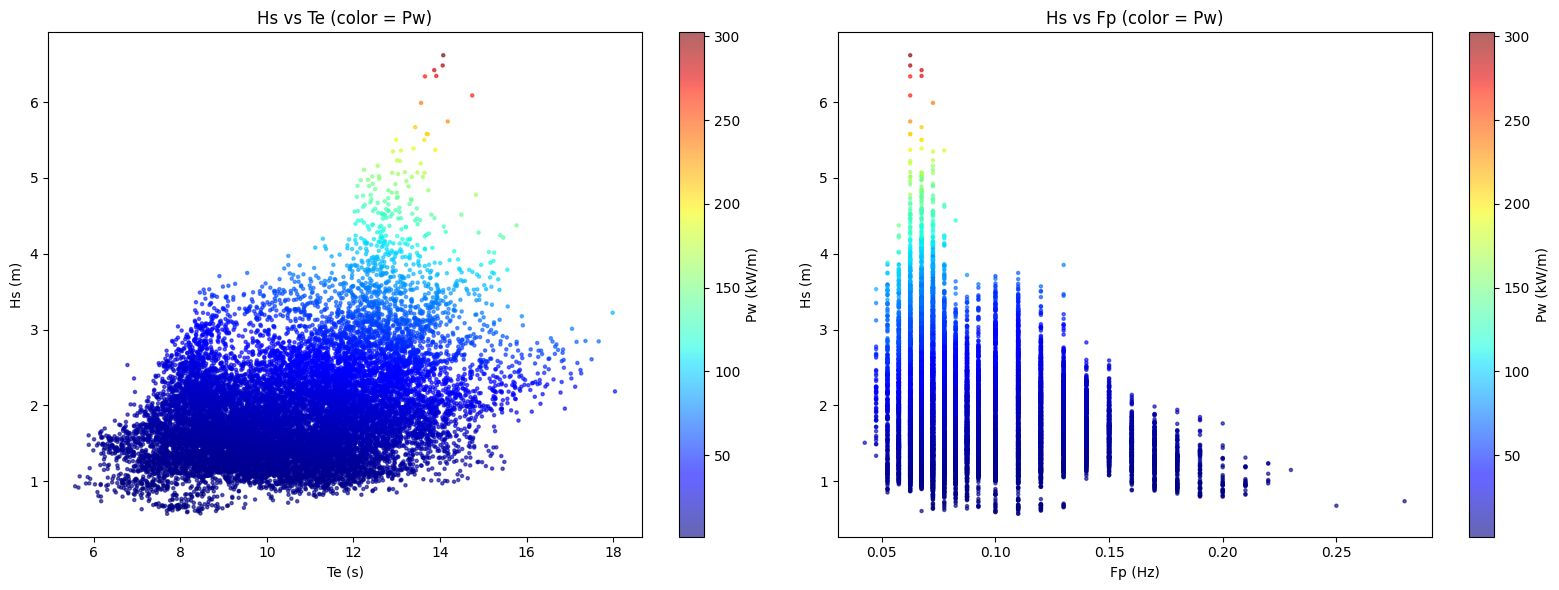

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Te vs Hs, color = Pw
sc1 = axes[0].scatter(df["Te (s)"], df["Hs (m)"], c=df["Pw (kW/m)"],
                       cmap="jet", s=5, alpha=0.6)
axes[0].set_xlabel("Te (s)")
axes[0].set_ylabel("Hs (m)")
axes[0].set_title("Hs vs Te (color = Pw)")
plt.colorbar(sc1, ax=axes[0], label="Pw (kW/m)")

# Scatter 2: Fp vs Hs, color = Pw
sc2 = axes[1].scatter(df["Fp (Hz)"], df["Hs (m)"], c=df["Pw (kW/m)"],
                       cmap="jet", s=5, alpha=0.6)
axes[1].set_xlabel("Fp (Hz)")
axes[1].set_ylabel("Hs (m)")
axes[1].set_title("Hs vs Fp (color = Pw)")
plt.colorbar(sc2, ax=axes[1], label="Pw (kW/m)")

plt.tight_layout()
plt.show()


## 10. Matriz de dispersión Hs–Te y energía anual — Método 2 (Punto 11)

El **Método 2** utiliza una tabla de doble entrada (*scatter matrix*) que clasifica las observaciones por rangos de $H_s$ y $T_e$. Para cada celda $(j, k)$ de la matriz:

1. Se cuenta el número de horas de ocurrencia.
2. Se calcula la potencia usando los centros de bin: $P_w(H_{s,j}, T_{e,k})$.
3. La energía total es: $E = \sum_j \sum_k P_w(H_{s,j}, T_{e,k}) \cdot \text{horas}(j,k)$

Este método difiere del Método 1 porque usa valores discretizados (centros de bin) en lugar de los valores exactos de cada observación, lo cual introduce un **error por discretización** que depende del tamaño de los bins.

Se utilizan bins de **0.5 m** para $H_s$ y **1.0 s** para $T_e$, que es la resolución estándar en estudios de ingeniería de costas.

In [15]:
# Definir bins
Hs_bin_width = 0.5  # metros
Te_bin_width = 1.0  # segundos

Hs_bins = np.arange(0, df["Hs (m)"].max() + Hs_bin_width, Hs_bin_width)
Te_bins = np.arange(0, df["Te (s)"].max() + Te_bin_width, Te_bin_width)

Hs_centers = (Hs_bins[:-1] + Hs_bins[1:]) / 2
Te_centers = (Te_bins[:-1] + Te_bins[1:]) / 2

# Asignar cada observación a un bin
df["Hs_bin"] = pd.cut(df["Hs (m)"], bins=Hs_bins, include_lowest=True)
df["Te_bin"] = pd.cut(df["Te (s)"], bins=Te_bins, include_lowest=True)

# Matriz de ocurrencia: registros en cada (Hs, Te)
occurrence = df.groupby(["Hs_bin", "Te_bin"], observed=False).size().unstack(fill_value=0)

# Pw para cada combinación de centros de bin
rho = 1025
g = 9.81
coeff = rho * g**2 / (64 * np.pi)

Pw_bin = np.zeros((len(Hs_centers), len(Te_centers)))
for j, hs in enumerate(Hs_centers):
    for k, te in enumerate(Te_centers):
        Pw_bin[j, k] = coeff * hs**2 * te / 1000  # kW/m

# Energía por bin = Pw × registros × Δt (0.5 h por registro)
dt = 0.5  # horas
E_bin = Pw_bin * occurrence.values * dt  # kWh/m

# Energía total (Método 2)
E_m2_kWh = E_bin.sum()
E_m2_MWh = E_m2_kWh / 1000
E_m2_GWh = E_m2_kWh / 1e6

print("=== Recurso energético anual (Método 2 — Matriz Hs-Te) ===\n")
print(f"Bins de Hs: {len(Hs_centers)} ({Hs_bins[0]:.1f} a {Hs_bins[-1]:.1f} m, ancho {Hs_bin_width} m)")
print(f"Bins de Te: {len(Te_centers)} ({Te_bins[0]:.1f} a {Te_bins[-1]:.1f} s, ancho {Te_bin_width} s)")
print(f"Total registros en matriz: {occurrence.values.sum()} (de {len(df)} observaciones)")
print(f"Δt por registro: {dt} h\n")
print(f"E = {E_m2_kWh:,.2f} kWh/m/año")
print(f"E = {E_m2_MWh:,.2f} MWh/m/año")
print(f"E = {E_m2_GWh:,.4f} GWh/m/año")

print(f"\n--- Comparación de métodos ---")
print(f"Método 1 (sumatoria directa): {E_directa_MWh:,.2f} MWh/m/año")
print(f"Método 2 (matriz Hs-Te):      {E_m2_MWh:,.2f} MWh/m/año")
print(f"Diferencia: {abs(E_m2_MWh - E_directa_MWh):,.2f} MWh/m/año "
      f"({abs(E_m2_MWh - E_directa_MWh) / E_directa_MWh * 100:.1f}%)")


=== Recurso energético anual (Método 2 — Matriz Hs-Te) ===

Bins de Hs: 14 (0.0 a 7.0 m, ancho 0.5 m)
Bins de Te: 19 (0.0 a 19.0 s, ancho 1.0 s)
Total registros en matriz: 15538 (de 15538 observaciones)
Δt por registro: 0.5 h

E = 181,954.34 kWh/m/año
E = 181.95 MWh/m/año
E = 0.1820 GWh/m/año

--- Comparación de métodos ---
Método 1 (sumatoria directa): 180.59 MWh/m/año
Método 2 (matriz Hs-Te):      181.95 MWh/m/año
Diferencia: 1.36 MWh/m/año (0.8%)


### Visualización de la matriz de dispersión

Se presentan dos heatmaps:
- **Izquierda:** Matriz de ocurrencia (número de horas por combinación de bins).
- **Derecha:** Contribución energética por bin (kWh/m), que muestra dónde se concentra el recurso.

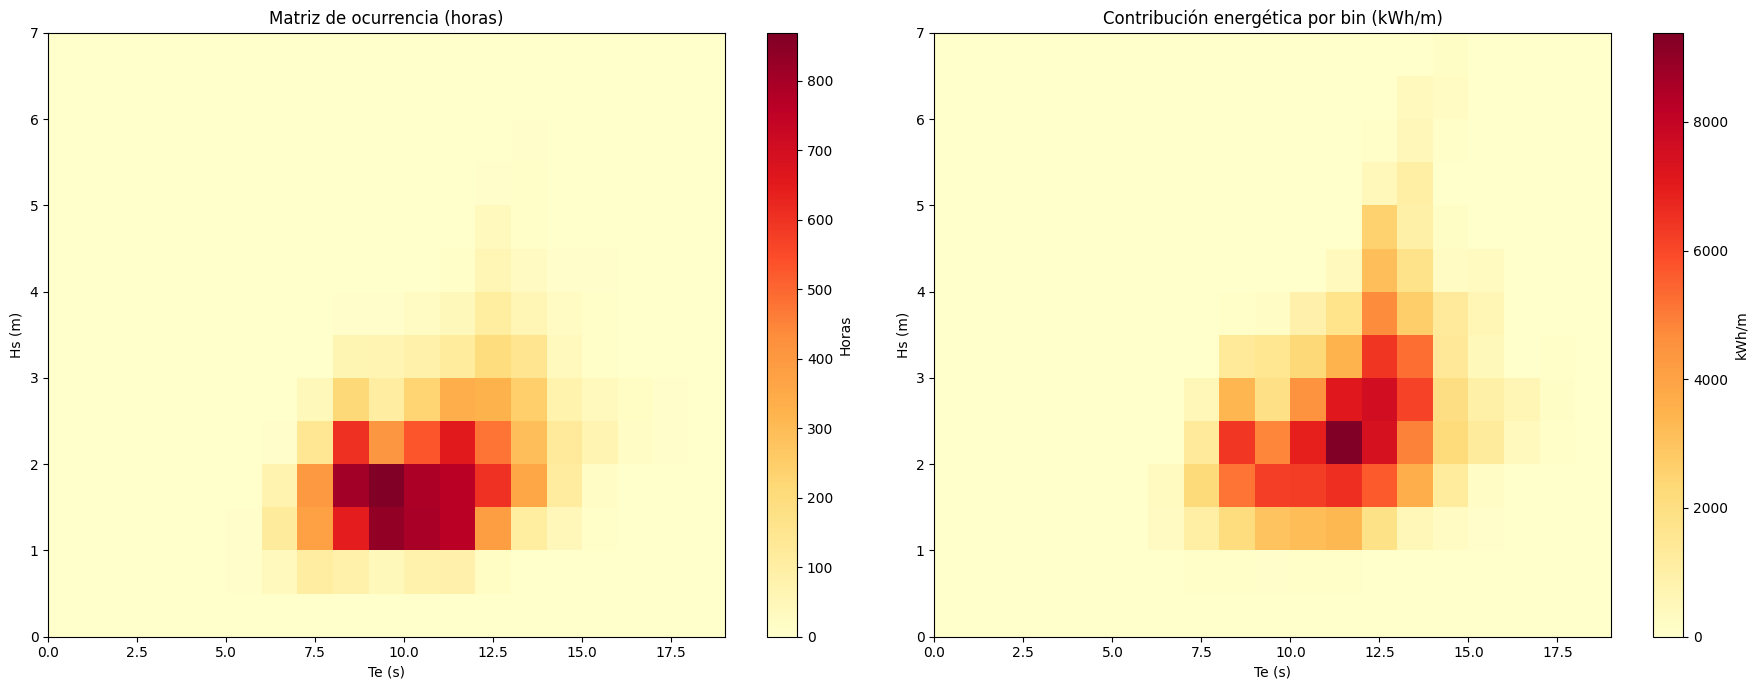

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de ocurrencia
im1 = axes[0].pcolormesh(Te_bins, Hs_bins, occurrence.values, cmap="YlOrRd", shading="flat")
axes[0].set_xlabel("Te (s)")
axes[0].set_ylabel("Hs (m)")
axes[0].set_title("Matriz de ocurrencia (horas)")
plt.colorbar(im1, ax=axes[0], label="Horas")

# Heatmap de contribución energética
im2 = axes[1].pcolormesh(Te_bins, Hs_bins, E_bin, cmap="YlOrRd", shading="flat")
axes[1].set_xlabel("Te (s)")
axes[1].set_ylabel("Hs (m)")
axes[1].set_title("Contribución energética por bin (kWh/m)")
plt.colorbar(im2, ax=axes[1], label="kWh/m")

plt.tight_layout()
plt.show()


## 11. Conclusiones

A partir del análisis espectral de un año de datos de oleaje (2025, ~15,538 registros cada 30 min), se obtuvieron los siguientes resultados:

**Caracterización del recurso:**
- Se determinó la potencia media anual del sitio, lo cual permite evaluar su potencial para aprovechamiento de energía undimotriz.
- El recurso presenta **estacionalidad**, con variaciones mensuales significativas en la potencia disponible.
- El mes de abril no cuenta con registros en los datos disponibles.

**Cálculos espectrales:**
- Los parámetros $H_s$, $T_e$ y $P_w$ calculados mediante momentos espectrales (usando $\Delta f$ promedio = 0.006556 Hz) coinciden con los valores pre-calculados del archivo, validando la implementación del método de Silva Casarín (2005).

**Recurso energético anual:**
- **Método 1** (sumatoria directa): proporciona el valor más preciso al usar cada registro individualmente con $\Delta t = 0.5$ h.
- **Método 2** (matriz de dispersión): introduce un pequeño error por discretización al usar centros de bin, pero tiene la ventaja de representar de forma compacta el clima de oleaje del sitio y facilitar el dimensionamiento de dispositivos WEC (*Wave Energy Converters*).

**Diagramas de dispersión:**
- La relación $H_s$–$T_e$ muestra que las condiciones de mayor potencia corresponden a oleaje con alturas significantes elevadas y períodos de energía largos, consistente con la dependencia cuadrática $P_w \propto H_s^2 T_e$.

---

## 12. Referencias

- Silva Casarín, R. (2005). *Análisis y descripción estadística del oleaje*. Serie Docencia, Instituto de Ingeniería, UNAM. pp. 61-65.
- Neill, S. P. & Hashemi, M. R. (2018). *Fundamentals of Ocean Renewable Energy*.
- Robertson, B. (2022). Distribución global de recursos de energía del oleaje.
- National Data Buoy Center (NDBC), NOAA. Datos de espectro de oleaje.